# Common Bean GART — `bean_gart_35462_35509`

|                        |                                          |
| ---------------------- | ---------------------------------------- |
| **Crop**               | Common bean (_Phaseolus vulgaris_)       |
| **Location**           | GART Chisamba, Zambia                    |
| **Year**               | 2025                                     |
| **Measurements**       | 9,716                                    |
| **Genotypes**          | 484 genotypes                            |
| **Owner**              | Kelvin Kamfwa                            |
| **Protocol**           | UNZA_PIRK_DIRK_LightPotential_14         |
| **PhotosynQ projects** | 35462, 35463, 35479, 35497, 35498, 35509 |

**Experiment:** Drought stress trial on three RIL (Recombinant Inbred Line) populations at Golden Valley Agricultural Research Trust (GART) in Zambia. Three bi-parental crosses — Lusaka × Krimson (LK), Lusaka × Inferno (LI), Mwezi Moja × Inferno (MI) — each measured under control and drought-stressed conditions.

| Project | Cross | Treatment | Measurements |
| ------- | ----- | --------- | ------------ |
| 35462   | LK    | Control   | 1,014        |
| 35479   | LK    | Stressed  | 1,836        |
| 35463   | LI    | Control   | 1,327        |
| 35497   | LI    | Stressed  | 2,433        |
| 35498   | MI    | Control   | 1,163        |
| 35509   | MI    | Stressed  | 1,943        |

**Computed columns (25):** Same UNZA_PIRK_DIRK protocol as Potato Grebbedijk — see Dataset 1.

**Additional column:** `sample_raw` (VARIANT).


In [ ]:
%pip install wadler-lindig -q

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_bean_gart

df = load_bean_gart(Path("data"))
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (9716, 44)
Columns: ['measurement_id', 'project_id', 'project_name', 'user_id', 'device_id', 'status', 'timestamp', 'latitude', 'longitude', 'genotype', 'rep', 'treatment', 'plot_id', 'sample_raw', 'note', 'project_description', 'protocol_name', 'project_location', 'phi2_ambient', 'phi2_high', 'LEF_ambient', 'LEF_high', 'LEF_light_potential', 'PAR', 'used_PAR_ambient', 'used_PAR_high', 'SQRT_PAR', 'SPAD', 'ambient_Temperature', 'leaf_temperature', 'leaf_temperature_differential', 'humidity', 'pressure', 'leaf_angle', 'PIRK_amp_ambient', 'PIRK_amp_high', 'pirk_intensity', 'autogain_ch1_duration', 'autogain_ch1_intensity', 'autogain_ch1_value', 'autogain_ch2_duration', 'autogain_ch2_intensity', 'autogain_ch2_value', 'measurement_duration_sec']


In [2]:
df.head()

,measurement_id,project_id,project_name,user_id,device_id,status,timestamp,latitude,longitude,genotype,...,PIRK_amp_ambient,PIRK_amp_high,pirk_intensity,autogain_ch1_duration,autogain_ch1_intensity,autogain_ch1_value,autogain_ch2_duration,autogain_ch2_intensity,autogain_ch2_value,measurement_duration_sec
0,5902210,35462,LK_Control_GART_2025,137094,11:16:72:44,submitted,2025-10-31 09:12:31.901000+00:00,-14.967073,28.099692,PRIME,...,0.180,0.212,2000.0,10.0,-3276.0,46581.0,20.0,-425.0,49410.0,34.060
1,5902209,35462,LK_Control_GART_2025,137094,11:16:72:44,submitted,2025-10-31 09:14:25.189000+00:00,-14.967073,28.099692,LK001,...,0.244,0.102,2000.0,10.0,-2942.0,49203.0,20.0,-425.0,47815.0,33.456
2,5902208,35462,LK_Control_GART_2025,137094,11:16:72:44,submitted,2025-10-31 09:18:50.233000+00:00,-14.967060,28.099683,LK002,...,0.181,0.307,2000.0,10.0,-2942.0,47613.0,20.0,-425.0,48283.0,32.801
3,5902207,35462,LK_Control_GART_2025,137094,11:16:72:44,submitted,2025-10-31 09:19:48.860000+00:00,-14.967060,28.099683,LK003,...,0.305,0.570,2000.0,10.0,-2200.0,49105.0,20.0,-425.0,47974.0,32.518
4,5902206,35462,LK_Control_GART_2025,137094,11:16:72:44,submitted,2025-10-31 09:21:27.559000+00:00,-14.967060,28.099683,LK004,...,0.189,0.228,2000.0,10.0,-2695.0,48603.0,20.0,-425.0,49151.0,32.776


## Exploratory Data Analysis


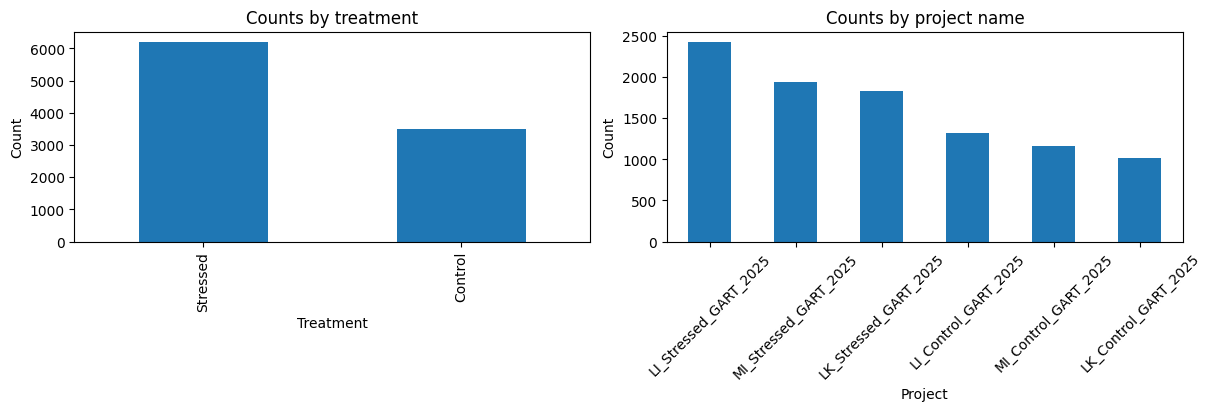

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

# Counts by treatment
df["treatment"].value_counts().plot(kind="bar", ax=axs[0])
axs[0].set(title="Counts by treatment", xlabel="Treatment", ylabel="Count")

# Counts by project_name
df["project_name"].value_counts().plot(kind="bar", ax=axs[1])
axs[1].set(title="Counts by project name", xlabel="Project", ylabel="Count")
axs[1].tick_params(axis="x", rotation=45)

Text(0.5, 0.98, 'KDE of key phenotype columns')

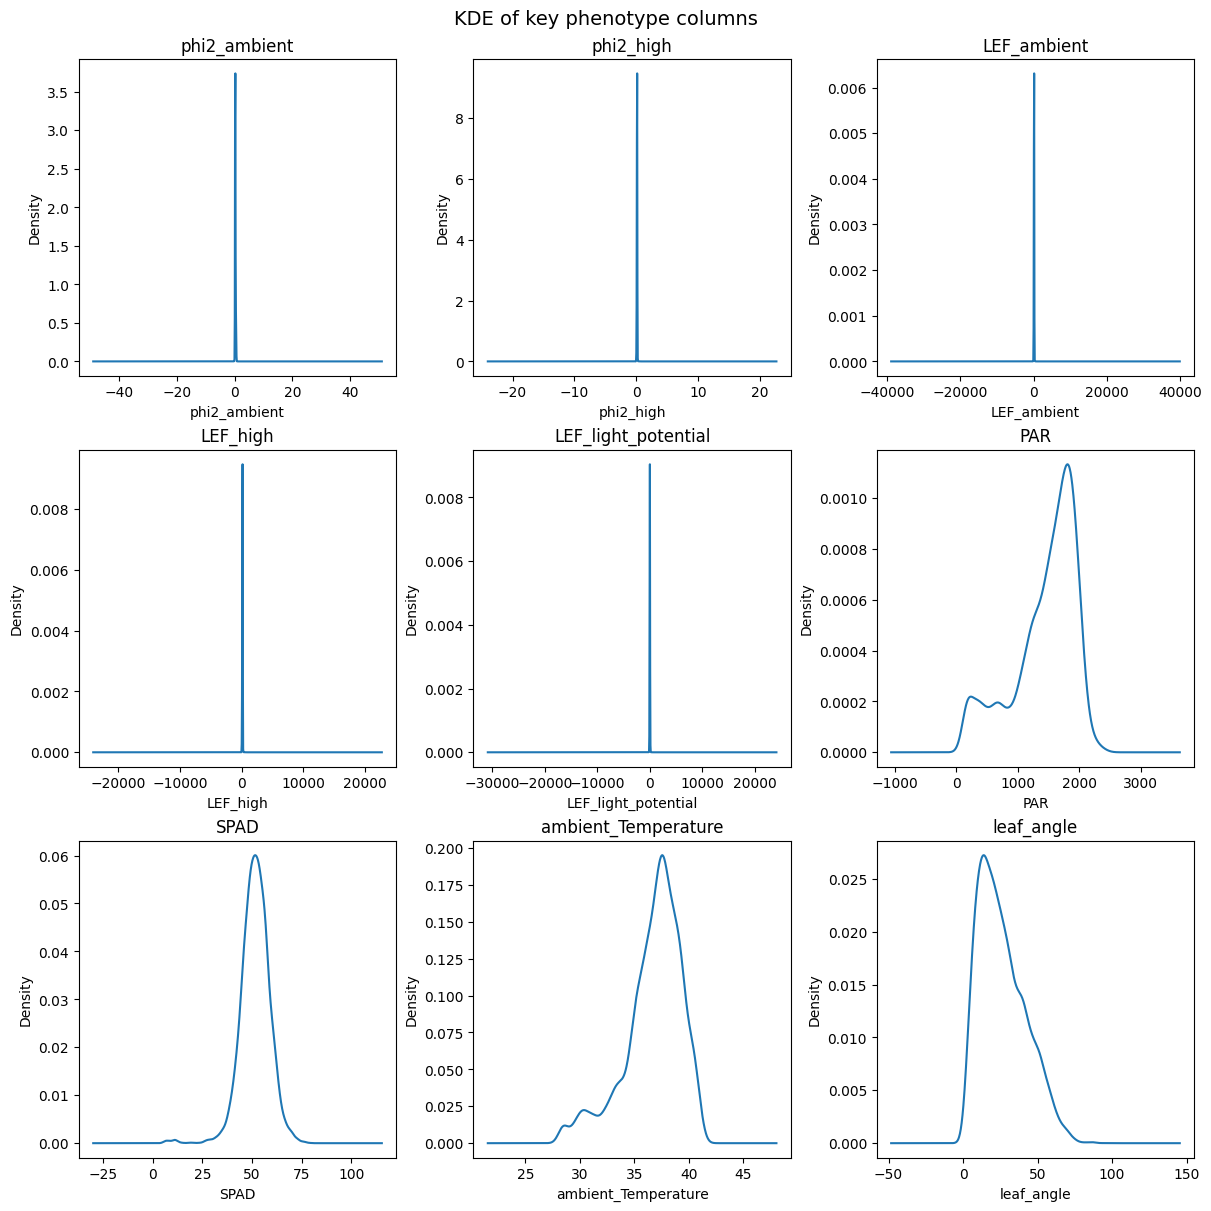

In [4]:
phenotype_cols = [
    "phi2_ambient",
    "phi2_high",
    "LEF_ambient",
    "LEF_high",
    "LEF_light_potential",
    "PAR",
    "SPAD",
    "ambient_Temperature",
    "leaf_angle",
]

fig, axs = plt.subplots(3, 3, figsize=(12, 12), layout="constrained")
for ax, col in zip(axs.flatten(), phenotype_cols):
    df[col].dropna().plot(kind="kde", ax=ax)
    ax.set(title=col, xlabel=col)
fig.suptitle("KDE of key phenotype columns", fontsize=14)

[Text(0.5, 1.0, 'LEF_light_potential by treatment')]

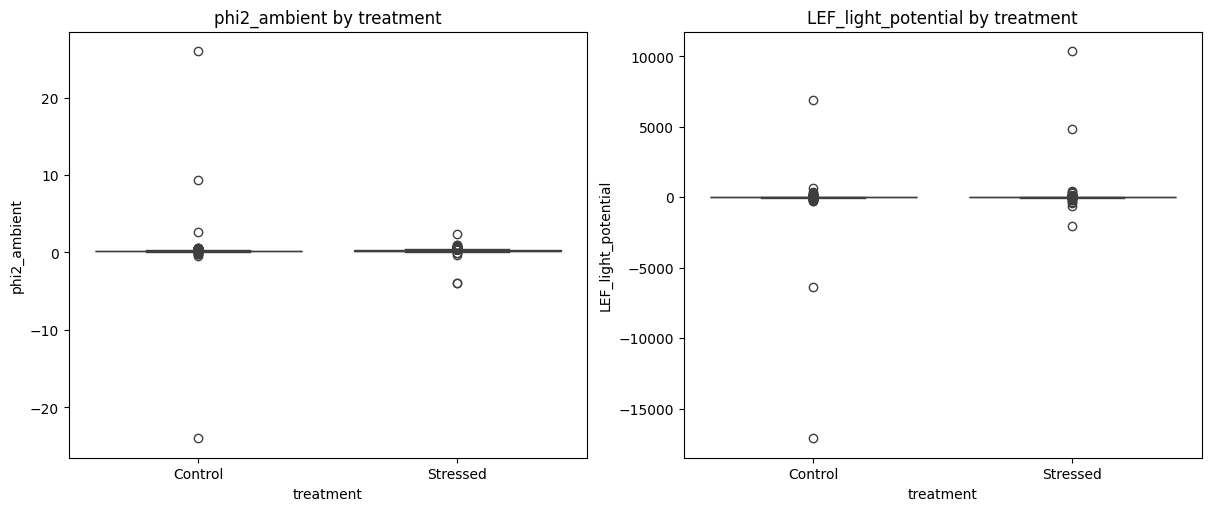

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

sns.boxplot(data=df, x="treatment", y="phi2_ambient", ax=axs[0])
axs[0].set(title="phi2_ambient by treatment")

sns.boxplot(data=df, x="treatment", y="LEF_light_potential", ax=axs[1])
axs[1].set(title="LEF_light_potential by treatment")

In [6]:
df.describe()

,latitude,longitude,phi2_ambient,phi2_high,LEF_ambient,LEF_high,LEF_light_potential,PAR,used_PAR_ambient,used_PAR_high,...,PIRK_amp_ambient,PIRK_amp_high,pirk_intensity,autogain_ch1_duration,autogain_ch1_intensity,autogain_ch1_value,autogain_ch2_duration,autogain_ch2_intensity,autogain_ch2_value,measurement_duration_sec
count,9716.000000,9716.000000,9716.000000,9716.000000,9716.000000,9716.000000,9716.000000,9716.000000,9716.000000,9716.0,...,9716.000000,9716.000000,9716.0,9716.0,9716.000000,9716.000000,9716.0,9716.000000,9716.000000,9716.000000
mean,-14.839515,27.860014,0.247073,0.131443,124.452355,131.438366,6.986011,1444.928932,1444.928076,2500.0,...,0.310248,0.193527,2000.0,10.0,-3305.372375,46466.812371,20.0,-484.864347,45230.365171,34.893891
std,1.377535,2.586200,0.390997,0.189883,297.030321,189.883017,231.903157,509.525079,509.525153,0.0,...,13.438348,0.445747,0.0,0.0,817.648212,2222.880974,0.0,53.695316,6196.766430,2.071597
min,-15.394443,0.000000,-24.000000,-12.333300,-19230.100000,-12333.330000,-17111.330000,113.200000,113.220000,2500.0,...,-438.020000,-21.262000,2000.0,10.0,-4294.000000,12964.000000,20.0,-1024.000000,4655.000000,31.260000
25%,-14.967450,28.099853,0.183800,0.118400,111.085000,118.425000,-5.050000,1204.000000,1203.991000,2500.0,...,0.080000,0.068000,2000.0,10.0,-4294.000000,44818.000000,20.0,-520.000000,43663.250000,33.382750
50%,-14.967375,28.099982,0.217400,0.135900,132.310000,135.895000,1.860000,1586.400000,1586.437000,2500.0,...,0.202000,0.179500,2000.0,10.0,-3276.000000,46551.000000,20.0,-486.000000,48088.000000,34.517500
75%,-14.967108,28.100133,0.276400,0.149800,145.182500,149.822500,12.090000,1824.925000,1824.902250,2500.0,...,0.327000,0.300000,2000.0,10.0,-2695.000000,48247.000000,20.0,-448.750000,49031.000000,35.874250
max,0.000000,28.334267,26.000000,11.000000,20254.190000,11000.000000,10379.700000,2462.900000,2462.918000,2500.0,...,1090.248000,6.775000,2000.0,10.0,-901.000000,59755.000000,20.0,-324.000000,59727.000000,66.519000


## Correlation Heatmap


In [ ]:
phenotype_corr_cols = [
    "phi2_ambient",
    "phi2_high",
    "LEF_ambient",
    "LEF_high",
    "LEF_light_potential",
    "PAR",
    "SPAD",
    "ambient_Temperature",
    "leaf_temperature_differential",
    "PIRK_amp_ambient",
    "PIRK_amp_high",
]

corr = df[phenotype_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8), layout="constrained")
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Phenotype Correlation Heatmap")
plt.show()

## Stress Response Analysis


In [ ]:
# Parse cross and condition from project_name
# project_name values are like "LK_Control_GART_2025", "LI_Stressed_GART_2025", etc.
print("Unique project_name values:", df["project_name"].unique())
print("Unique treatment values:", df["treatment"].unique())

df["cross"] = df["project_name"].str.split("_").str[0]
df["condition"] = df["project_name"].str.split("_").str[1]

print("\nParsed crosses:", df["cross"].unique())
print("Parsed conditions:", df["condition"].unique())

# Group by cross and condition
stress_summary = (
    df.groupby(["cross", "condition"])[["phi2_ambient", "LEF_light_potential"]]
    .mean()
    .reset_index()
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

for ax, col in zip(axs, ["phi2_ambient", "LEF_light_potential"]):
    pivot = stress_summary.pivot(index="cross", columns="condition", values=col)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"{col} — Control vs Stressed by Cross")
    ax.set_xlabel("Cross")
    ax.set_ylabel(col)
    ax.legend(title="Condition")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Stress Response across RIL Populations", fontsize=14)
plt.show()

## Heritability


In [ ]:
from src import drop_na_multiple, heritability, heritability_with_covariates

# Phenotype data for heritability analysis
data, gtype = drop_na_multiple(
    df[["phi2_ambient", "phi2_high", "LEF_ambient", "LEF_high", "LEF_light_potential"]],
    df["genotype"],
)

# Filter out genotypes with fewer than 3 entries
more_than_3 = gtype.groupby(gtype).transform("size") > 3
data = data[more_than_3]
gtype = gtype[more_than_3]

print(f"Samples after cleaning: {len(data)}")
print(f"Unique genotypes: {gtype.nunique()}")

h2 = heritability(data=data, gtype=gtype)
_ = h2.plot()
h2.as_frame()

In [ ]:
# Heritability with covariates — treatment as environmental factor
# Re-clean including treatment as env_factors
data_cov, env_factors, gtype_cov = drop_na_multiple(
    df[["phi2_ambient", "phi2_high", "LEF_ambient", "LEF_high", "LEF_light_potential"]],
    df[["project_name"]],
    df["genotype"],
)

# Filter out genotypes with fewer than 3 entries
more_than_3 = gtype_cov.groupby(gtype_cov).transform("size") > 3
data_cov = data_cov[more_than_3]
env_factors = env_factors[more_than_3]
gtype_cov = gtype_cov[more_than_3]

# Encode treatment as numeric using pd.get_dummies for the linear model
env_factors_numeric = pd.get_dummies(env_factors, drop_first=True).astype(float)
print(f"Environment factor columns: {list(env_factors_numeric.columns)}")

h2_cov = heritability_with_covariates(
    data=data_cov,
    env_factors=env_factors_numeric,
    gtype=gtype_cov,
)
_ = h2_cov.plot()
h2_cov.as_frame()